# 02 — Data Preprocessing

In the EDA notebook we identified three problems that block modelling:

1. **Anomalous values** — placeholder codes (96, 98) in the late-payment
   counters, an impossible `age = 0`, and extreme right-tail values in
   `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio`.
2. **Missing data** — `MonthlyIncome` (~20%) and `NumberOfDependents` (~2.6%).
3. **Severe class imbalance** — only ~6.7% of clients are delinquent
   (`SeriousDlqin2yrs = 1`).

This notebook turns the raw data into a clean, model-ready dataset.

**Methodological principle — no data leakage.**
Every transformation that *learns a parameter from the data* (imputation
medians, winsorisation caps, synthetic oversampling) is fitted **only on the
training split** and then applied to the test split. We therefore split
*first*, before touching anything else.

Pipeline: split → clean → impute → (analyse imbalance) → resample.

In [2]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_column", None)

In [3]:
RAW_PATH = Path("../data/cs-training.csv")
df = pd.read_csv(RAW_PATH, index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1. Recap of the issues to fix

| Issue | Columns | Action |
|---|---|---|
| Placeholder codes 96 / 98 | the three `NumberOfTime…PastDue…` counters | treat as missing, then impute |
| Impossible value `age = 0` | `age` | treat as missing, then impute |
| Heavy right tails | `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` | winsorise at a train-derived cap |
| Missing values | `MonthlyIncome`, `NumberOfDependents` | median imputation + missingness flag |
| Class imbalance | target `SeriousDlqin2yrs` | resample the training set |

In [4]:
print("Missing values (%):")
print((df.isna().mean() * 100).round(2).sort_values(ascending=False).head())

print("\nTarget distribution:")
print(df["SeriousDlqin2yrs"].value_counts(normalize=True).round(4))

Missing values (%):
MonthlyIncome                           19.82
NumberOfDependents                       2.62
SeriousDlqin2yrs                         0.00
age                                      0.00
RevolvingUtilizationOfUnsecuredLines     0.00
dtype: float64

Target distribution:
SeriousDlqin2yrs
0    0.9332
1    0.0668
Name: proportion, dtype: float64


## 2. Train/test split (done first, to prevent leakage)

We hold out 20% as a final test set. The split is **stratified** on the target
so that the rare positive class keeps the same proportion in both splits —
without stratification a random split could leave the test set with too few
positives to evaluate reliably.

Model selection (cross-validation, hyper-parameter tuning) will be done **inside
the training split** in the modelling notebook; the test split stays untouched
until the very end.

In [5]:
TARGET = "SeriousDlqin2yrs"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Work on independent copies to avoid pandas SettingWithCopy warnings
X_train, X_test = X_train.copy(), X_test.copy()

print(X_train.shape, X_test.shape)

(120000, 10) (30000, 10)


## 3. Missingness indicators

Before we impute, we record *where* the data was missing for the two columns
with substantial missingness. The reason is conceptual:

- If income is **MCAR** (missing completely at random), the fact of being
  missing carries no signal.
- But income missingness here is plausibly **MNAR** — a client who does not
  report income may differ systematically in risk. Throwing that away loses
  signal.

So we keep a binary flag `<col>_missing` *and* impute the value itself. The flag
lets the models decide whether "the value was absent" is itself predictive.

In [6]:
missing_flag_cols = ["MonthlyIncome", "NumberOfDependents"]

for col in missing_flag_cols:
    X_train[f"{col}_missing"] = X_train[col].isna().astype(int)
    X_test[f"{col}_missing"] = X_test[col].isna().astype(int)

## 4. Cleaning anomalous values

- **Codes 96 and 98** in the late-payment counters are not plausible counts
  (the realistic range is roughly 0–13). We treat them as missing and let the
  imputer handle them, rather than inventing a count.
- **`age = 0`** is impossible for a credit applicant → treated as missing.
- **Heavy right tails** in `RevolvingUtilizationOfUnsecuredLines` and
  `DebtRatio` (values in the thousands, far above any sensible ratio) are
  **winsorised**: clipped at the 99th percentile **computed on the training set**.
  Clipping keeps the row (we don't lose data) while removing the leverage that a
  handful of extreme points would otherwise have on scale-sensitive steps.

All thresholds come from `X_train` only; the same numbers are reused on the test
set so no test information leaks into the cleaning rules.

In [7]:
def clean_features(data: pd.DataFrame, caps: dict) -> pd.DataFrame:
    """Replace anomalous values with NaN and winsorise heavy-tailed columns.

    `caps` maps a column name to its upper clip value, derived from the
    training set, so the function stays leakage-free on the test set.
    """
    data = data.copy()

    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]
    # 96 / 98 are placeholder codes, not real counts -> mark as missing
    for col in past_due_cols:
        data[col] = data[col].mask(data[col].isin([96, 98]))

    # age of 0 is impossible -> mark as missing
    data["age"] = data["age"].mask(data["age"] == 0)

    # winsorise the heavy-tailed ratios at train-derived upper caps
    for col, upper in caps.items():
        data[col] = data[col].clip(upper=upper)

    return data


cap_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]
caps = {col: X_train[col].quantile(0.99) for col in cap_cols}  # learned on train only
print("Winsorisation caps (from train):", {k: round(v, 2) for k, v in caps.items()})

X_train = clean_features(X_train, caps)
X_test  = clean_features(X_test, caps)

Winsorisation caps (from train): {'RevolvingUtilizationOfUnsecuredLines': np.float64(1.09), 'DebtRatio': np.float64(4977.0)}


## 5. Missing-value imputation

We impute with the **median**, fitted on the training set.

Why median rather than mean? `MonthlyIncome` is strongly right-skewed. The mean
minimises squared error (L2) and is dragged toward the long right tail, so it
overestimates a "typical" client. The median minimises absolute error (L1) and
is robust to skew and outliers — a better stand-in for a central value here.

The same median learned on train fills both splits, so the test set never
contributes to the imputation values.

In [8]:
imputer = SimpleImputer(strategy="median")
imputer.set_output(transform="pandas")  # keep a DataFrame with column names

X_train = imputer.fit_transform(X_train)   # fit on train
X_test  = imputer.transform(X_test)        # apply the same medians to test

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
print("No missing values remain.")
X_train.head()

No missing values remain.


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
57837,0.114987,62.0,0.0,1841.000000,5390.0,5.0,0.0,1.0,0.0,2.0,1.0,0.0
132896,0.008705,73.0,0.0,0.498553,3800.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0
27982,0.214501,32.0,0.0,0.211999,3716.0,8.0,0.0,0.0,0.0,2.0,0.0,0.0
37853,1.000000,60.0,0.0,118.000000,5390.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0
103814,0.230493,60.0,0.0,1.017328,3000.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0


## 6. Save the cleaned, imputed splits

These are the model-ready inputs (still **unscaled** — scaling is model-specific
and belongs in the modelling pipelines: linear models need it, tree-based models
do not). We also persist the fitted imputer and the caps so the exact same
transformation can be reproduced on any future data.

In [9]:
PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

X_train.to_csv(PROCESSED / "X_train.csv", index=False)
X_test.to_csv(PROCESSED / "X_test.csv", index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False)
y_test.to_csv(PROCESSED / "y_test.csv", index=False)

joblib.dump(imputer, PROCESSED / "imputer.joblib")
joblib.dump(caps, PROCESSED / "caps.joblib")

print("Saved cleaned splits and transformers to", PROCESSED)

Saved cleaned splits and transformers to data\processed


## 7. Class imbalance

Only ~6.7% of the training clients are delinquent. Two consequences:

**The accuracy paradox.** A trivial model that always predicts "not delinquent"
already scores ~93% accuracy while being useless — it never flags a single
risky client. Accuracy is therefore the wrong metric here (we will rely on
ROC-AUC, PR-AUC and recall in the evaluation notebook).

**Biased optimisation.** Empirical risk is an average over examples,
`R = (1/N) Σ L(y_i, ŷ_i)`. With 93% of the terms coming from the majority class,
the majority dominates the loss and the learned decision boundary is pulled
toward predicting the majority. We need to rebalance the *effective* influence
of the two classes during training.

SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64
Majority : minority ratio = 14.0 : 1


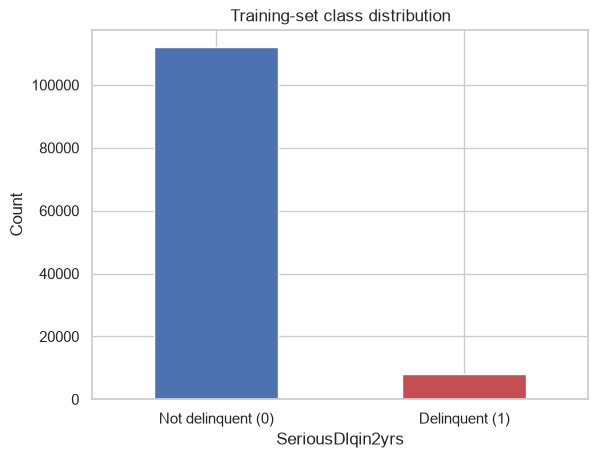

In [10]:
counts = y_train.value_counts().sort_index()
ratio = counts[0] / counts[1]
print(counts)
print(f"Majority : minority ratio = {ratio:.1f} : 1")

counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.xticks([0, 1], ["Not delinquent (0)", "Delinquent (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Training-set class distribution")
plt.show()

## 8. Oversampling with SMOTE

We rebalance the **training set only** using SMOTE (Synthetic Minority
Over-sampling Technique, Chawla et al., 2002). Instead of duplicating minority
rows (which just teaches the model the same points harder, risking overfitting),
SMOTE *synthesises* new minority examples.

**The algorithm.** For a minority sample `x`, find its `k` nearest minority
neighbours. Pick one neighbour `x̃` at random, draw `λ ~ Uniform(0, 1)`, and
create:

$$x_{\text{new}} = x + \lambda \,(\tilde{x} - x)$$

Geometrically, `x_new` is a random point on the segment between `x` and a
neighbour — so SMOTE fills in the minority region rather than just thickening
existing points. Repeat until the classes are balanced.

**A subtlety with our data.** We engineered binary flags (`*_missing`). Plain
SMOTE interpolates *every* feature linearly, which would turn a 0/1 flag into a
meaningless fractional value like 0.37. The correct tool is **SMOTENC**, which
handles continuous features by interpolation and categorical/binary features by
a nearest-neighbour majority vote, keeping them at clean 0/1 values.

### Why SMOTENC and not plain SMOTE?

Our feature matrix is **mixed-type**: it contains both continuous variables
(income, ratios, counts) and the two binary missingness flags we engineered
(`MonthlyIncome_missing`, `NumberOfDependents_missing`).

Plain SMOTE treats every feature as continuous and creates a synthetic point by
linear interpolation:

$$x_{\text{new}} = x + \lambda\,(\tilde{x} - x), \quad \lambda \sim U(0,1)$$

For a binary flag this produces a nonsensical real-valued result.
For example, if `x[flag] = 0` and `x̃[flag] = 1`, the synthetic value is
`λ = 0.37` — a feature that was designed to mean "income was missing (1) or
not (0)" now takes an uninterpretable value. This corrupts the feature's
semantics and sends noisy signals to every downstream model.

**SMOTENC** (Chawla et al., 2002, extended) handles each feature type
differently:

| Feature type | Synthesis rule |
|---|---|
| Continuous | Standard interpolation: `x + λ(x̃ − x)` |
| Categorical / binary | Majority vote among the `k` nearest minority neighbours |

For the binary flags, the majority vote keeps the value at exactly 0 or 1,
preserving their intended meaning.

An alternative would be to **one-hot-encode first, apply plain SMOTE, then
reverse-decode** — but this adds two error-prone steps and for simple binary
flags offers no benefit over SMOTENC.

**Pros of SMOTENC for this dataset:**
- Generates semantically valid synthetic samples when the feature space is mixed.
- No pre/post encoding steps; the flags stay readable throughout.
- Inherits all advantages of SMOTE over naive duplication (explores the minority
  manifold rather than repeating points).

**Cons and caveats:**
- Requires explicitly listing categorical column indices; a mistake silently
  corrupts the synthesis.
- The majority-vote rule is a simplification: it does not learn the conditional
  distribution of the flag given the continuous features, only the marginal
  plurality among neighbours.
- Like all SMOTE variants, it synthesises in feature space, not in the true
  data-generating process — synthetic examples may not correspond to any
  realistic credit applicant.
- Introduces a hyperparameter (`k_neighbors = 5`) whose sensitivity we do not
  tune in this notebook; modelling notebook experiments will compare SMOTENC
  against the class-weighting alternative to check whether the choice matters.

In [11]:
cat_cols = ["MonthlyIncome_missing", "NumberOfDependents_missing"]
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(
    categorical_features=cat_idx,
    random_state=RANDOM_STATE,
    k_neighbors=5,
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().to_dict())
print("After: ", y_train_res.value_counts().to_dict())

Before: {0: 111979, 1: 8021}
After:  {0: 111979, 1: 111979}


## 9. Alternatives and an important caveat

SMOTE is one option among several, and we will compare it against a no-resampling
baseline in the modelling notebook:

- **Class weights / cost-sensitive learning** — reweight the loss so each
  minority error counts more, e.g. `w_c = N / (K · N_c)`. No synthetic data, no
  leakage risk; supported via `class_weight="balanced"` (LogReg, trees) and
  `scale_pos_weight` (XGBoost). Often a very strong, simpler baseline.
- **Random undersampling** — discards majority rows; loses information.
- **ADASYN / BorderlineSMOTE** — variants that focus synthesis near the
  decision boundary.

**Caveat on where SMOTE belongs.** The statistically correct way to use SMOTE
with cross-validation is to apply it **inside each CV fold**, on the fold's
training portion only — never on the validation portion. If synthetic samples
leaked into validation folds, the scores would be optimistically biased.

For that reason, the resampled file we save below is a **convenience artifact**
for quick baselines and inspection. In the modelling notebook the rigorous
comparison will wrap resampling in an `imblearn` pipeline so it runs per-fold:

```python
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTENC(categorical_features=cat_idx, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000)),
])
# used with cross_val_score -> SMOTE is fitted only on each training fold
```

In [13]:
X_train_res.to_csv(PROCESSED / "X_train_resampled.csv", index=False)
y_train_res.to_csv(PROCESSED / "y_train_resampled.csv", index=False)
print("Saved resampled training set to", PROCESSED)

Saved resampled training set to data\processed


## 10. Summary

Starting from the raw data we:

1. split off a stratified 20% test set before any fitting,
2. flagged and cleaned anomalous values (codes 96/98, `age = 0`, heavy tails),
3. imputed missing values with train-derived medians plus missingness flags,
4. analysed the 14:1 class imbalance and produced a SMOTENC-resampled training
   set, while noting that the final modelling comparison will run resampling
   inside cross-validation to stay leakage-free.

**Artifacts produced:** `X_train/X_test/y_train/y_test`, `X_train_resampled`,
`y_train_resampled`, plus the fitted `imputer` and `caps`.

**Next (03 — Modelling):** train and compare Logistic Regression, Decision Tree,
Random Forest and XGBoost, with and without resampling, using cross-validation.